In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Polynomail_regression-Prac-D2.csv')
df.head()

Saving Polynomail_regression-Prac-D2.csv to Polynomail_regression-Prac-D2 (1).csv


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
print("/nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

/nDataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None

Summary Statistics:
               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
m

In [ ]:
df.shape

(414, 8)

In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
df.dtypes

,0
No,int64
X1 transaction date,float64
X2 house age,float64
X3 distance to the nearest MRT station,float64
X4 number of convenience stores,int64
X5 latitude,float64
X6 longitude,float64
Y house price of unit area,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
df.duplicated().any()

np.False_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['X1 transaction date'] = pd.to_numeric(df['X1 transaction date'], errors='coerce')
df['X2 house age'] = pd.to_numeric(df['X2 house age'], errors='coerce')

In [ ]:
df = df.dropna(subset=['X1 transaction date', 'X2 house age'])

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
print("\n Cleaned Structured Dataset:\n", df.head(10))
print("\nDataset Info After Cleaning:")
print(df.info())


 Cleaned Structured Dataset:
    No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   
5   6             2012.667           7.1   
6   7             2012.667          34.5   
7   8             2013.417          20.3   
8   9             2013.500          31.7   
9  10             2013.417          17.9   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   
5               

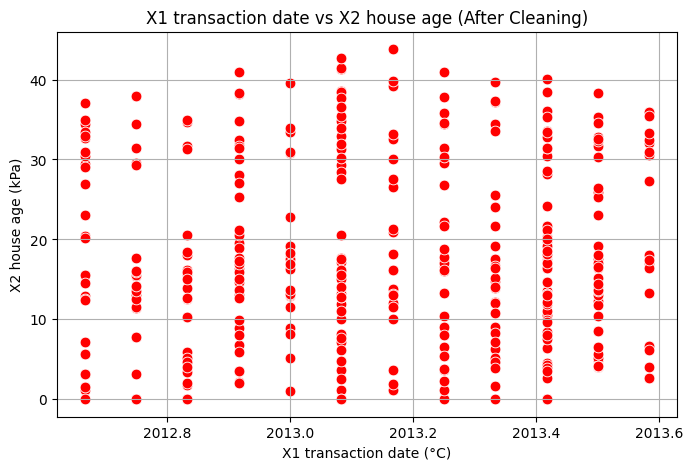

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='X1 transaction date', y='X2 house age', data=df, color='red', s=60)
plt.title("X1 transaction date vs X2 house age (After Cleaning)")
plt.xlabel("X1 transaction date (°C)")
plt.ylabel("X2 house age (kPa)")
plt.grid(True)
plt.show()

In [ ]:
x = df[['X1 transaction date']].values
y = df['X2 house age'].values

In [ ]:
# step : Linear Regreassion (Baseline)

lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred_linear = lin_reg.predict(x)
r2_linear = r2_score(y,y_pred_linear)

In [ ]:
# step 4: polynomial Reggresion (Degree 2 and 3)
# Degree 2 (quadractic)

poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(x)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [ ]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(x)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [ ]:
# Step 5: Evaluate Models
print("\n Model Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


 Model Performance Comparison:
Linear Regression R² Score: 0.0003
Polynomial (Degree 2) R² Score: 0.0011
Polynomial (Degree 3) R² Score: 0.0011


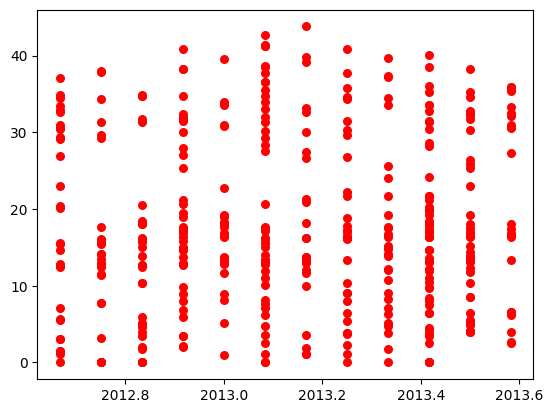

In [ ]:
# Sctter data
plt.scatter(x,y,color='red',label='Actual Data',s=30)

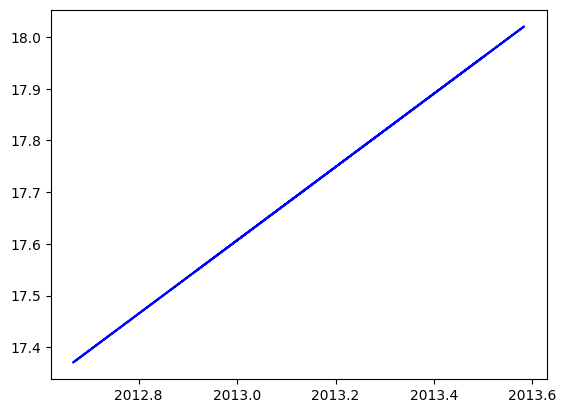

In [ ]:
# Linear Regression line
plt.plot(x,y_pred_linear, color='blue', label=f'Linear Fit (R={r2_linear:.3f}')

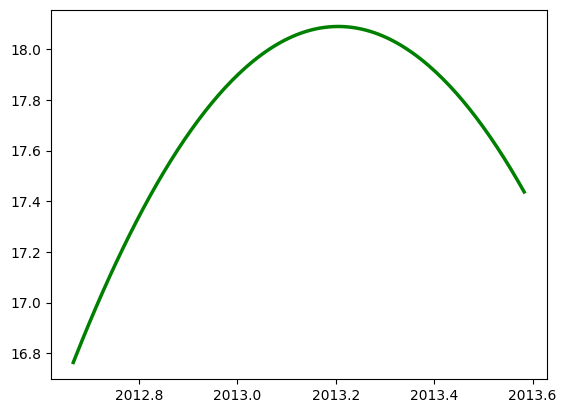

In [ ]:
# Polynomial (Degree 2) curve
x_grid = np.linspace(min(x), max(x), 200).reshape(-1,1)
plt.plot(x_grid, poly_reg2.predict(poly2.transform(x_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

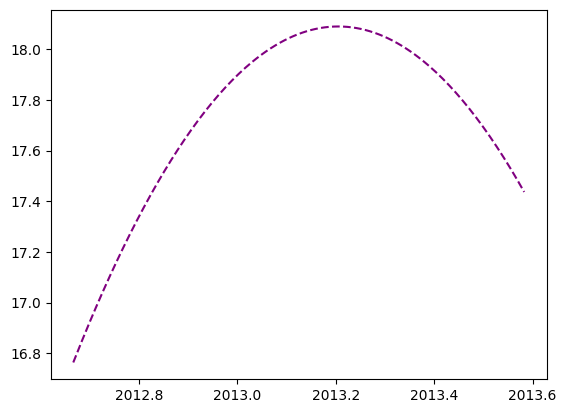

In [ ]:
# Polynomial Degree 3
plt.plot(x_grid, poly_reg3.predict(poly3.transform(x_grid)), color='purple',linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R={r2_poly3:.3f})')

In [ ]:
# Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [ 0.00000000e+00  1.84369967e+04 -4.57901560e+00]
Degree 2 Intercept: -18558711.295267105
Degree 2 MSE: 129.3371

Degree 3 Coefficients: [ 0.00000000e+00  2.27453648e-03  4.57890888e+00 -1.51629161e-03]
Degree 3 Intercept: -6186084.088888268
Degree 3 MSE: 129.3371


**Conclusion**

The dataset contains Position, Level, and Salary columns, where Position represents job designation, Level indicates the employee hierarchy level. The objective was to predict Level based on Salary using regression models
The Linear Regression model achieved an R? score of 0.6690, showing prediction accuracy and indicating that a straight-line relationship does not fit the data well. In comparison, Polynomial Regression Degree 2 significantly improved the model with an R? score of 0.9093 and MSE of 0.7482. Further improvement was observed with Polynomial Regression Degree 3, which achieved the highest R score of 0.9769 and the lowest MSE of 0.1908
The Degree 2 and Degree 3 polynomial coefficients and intercept values helped capture the non-linear relationship between Salary and Level. Since the Degree 3 model provides the highest accuracy and lowest prediction error, it is considered the best model for this dataset. This shows that employee salary and level have a strong non-linear relationship, which polynomial regression models can capture more effectively than linear regression.